In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_df = pd.read_csv('/workspaces/telecom-customer-churn-ml-project/data/raw/train.csv')

In [4]:
df = pd.read_csv('/workspaces/telecom-customer-churn-ml-project/data/raw/train.csv')

In [5]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,3071-VBYPO,Male,38,Yes,2,Whittier,90604,33.929704,-118.012080,1,...,Bank Withdrawal,89.85,248.40,0.0,0,99.90,348.30,Joined,NaN,NaN
1,2362-IBOOY,Male,22,No,0,San Diego,92126,32.886925,-117.152162,0,...,Bank Withdrawal,84.75,3050.15,0.0,0,1582.92,4633.07,Churned,Competitor,Competitor made better offer
2,8610-WFCJF,Female,53,Yes,0,Palo Alto,94303,37.458090,-122.115398,2,...,Bank Withdrawal,95.60,4783.50,0.0,0,2431.87,7215.37,Churned,Competitor,Competitor offered higher download speeds
3,2026-TGDHM,Female,54,No,0,Cloverdale,95425,38.801936,-122.938935,0,...,Bank Withdrawal,79.30,523.15,0.0,10,134.47,667.62,Churned,Competitor,Competitor had better devices
4,9588-OZDMQ,Female,38,Yes,0,Tollhouse,93667,36.993666,-119.348267,8,...,Bank Withdrawal,45.00,89.75,0.0,0,31.00,120.75,Joined,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        5634 non-null   str    
 1   Gender                             5634 non-null   str    
 2   Age                                5634 non-null   int64  
 3   Married                            5634 non-null   str    
 4   Number of Dependents               5634 non-null   int64  
 5   City                               5634 non-null   str    
 6   Zip Code                           5634 non-null   int64  
 7   Latitude                           5634 non-null   float64
 8   Longitude                          5634 non-null   float64
 9   Number of Referrals                5634 non-null   int64  
 10  Tenure in Months                   5634 non-null   int64  
 11  Offer                              2557 non-null   str    
 12  Pho

In [7]:
df.columns.tolist()

['Customer ID',
 'Gender',
 'Age',
 'Married',
 'Number of Dependents',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Customer Status',
 'Churn Category',
 'Churn Reason']

In [8]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,5634,5634,3071-VBYPO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5634,2,Male,2860,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5634.0,NaN,NaN,NaN,46.48935,16.854406,19.0,32.0,46.0,60.0,80.0
Married,5634,2,No,2888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,5634.0,NaN,NaN,NaN,0.468939,0.96311,0.0,0.0,0.0,0.0,9.0
City,5634,1104,Los Angeles,243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,5634.0,NaN,NaN,NaN,93469.327299,1855.680856,90001.0,92078.0,93512.0,95321.75,96150.0
Latitude,5634.0,NaN,NaN,NaN,36.177783,2.458365,32.555828,33.991782,36.04533,38.135897,41.962127
Longitude,5634.0,NaN,NaN,NaN,-119.754696,2.155592,-124.301372,-121.801599,-119.526897,-117.98588,-114.192901
Number of Referrals,5634.0,NaN,NaN,NaN,1.965744,3.006661,0.0,0.0,0.0,3.0,11.0


In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Churn Reason                         4138
Churn Category                       4138
Offer                                3077
Online Backup                        1208
Avg Monthly GB Download              1208
Online Security                      1208
Streaming Movies                     1208
Streaming TV                         1208
Unlimited Data                       1208
Streaming Music                      1208
Internet Type                        1208
Device Protection Plan               1208
Premium Tech Support                 1208
Avg Monthly Long Distance Charges     560
Multiple Lines                        560
dtype: int64

In [10]:
#remove high missing value columns
columns_to_drop = [
    "Churn Reason",
    "Churn Category",
    "Offer",
    "Customer ID"
]

df = df.drop(columns=columns_to_drop, errors="ignore")



In [11]:
df["Internet Service"].value_counts(dropna=False)

Internet Service
Yes    4426
No     1208
Name: count, dtype: int64

### cleaning columns

In [12]:
import numpy as np

numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

Categorical Columns:
['Gender', 'Married', 'City', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status']


/tmp/ipykernel_15705/401532889.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


In [13]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['gender', 'age', 'married', 'number_of_dependents', 'city', 'zip_code',
       'latitude', 'longitude', 'number_of_referrals', 'tenure_in_months',
       'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'customer_status'],
      dtype='str')

In [14]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical Columns:")
print(categorical_columns)


Categorical Columns:
['gender', 'married', 'city', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'customer_status']


/tmp/ipykernel_15705/3685563889.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


## Categorical Columns

In [15]:
df['gender'] = df['gender'].replace({
    'Male': 'M',
    'Female': 'F',
    
})

df['gender'].value_counts()

gender
M    2860
F    2774
Name: count, dtype: int64

In [16]:
for column in categorical_columns:
    print(f"\nValue count for {column}:")
    print(df[column].value_counts())


Value count for gender:
gender
M    2860
F    2774
Name: count, dtype: int64

Value count for married:
married
No     2888
Yes    2746
Name: count, dtype: int64

Value count for city:
city
Los Angeles          243
San Diego            230
San Jose              88
San Francisco         86
Sacramento            85
                    ... 
Tulelake               1
Green Valley Lake      1
Pilot Hill             1
Atherton               1
Smartville             1
Name: count, Length: 1104, dtype: int64

Value count for phone_service:
phone_service
Yes    5074
No      560
Name: count, dtype: int64

Value count for multiple_lines:
multiple_lines
No     2715
Yes    2359
Name: count, dtype: int64

Value count for internet_service:
internet_service
Yes    4426
No     1208
Name: count, dtype: int64

Value count for internet_type:
internet_type
Fiber Optic    2438
DSL            1308
Cable           680
Name: count, dtype: int64

Value count for online_security:
online_security
No     2818
Yes  

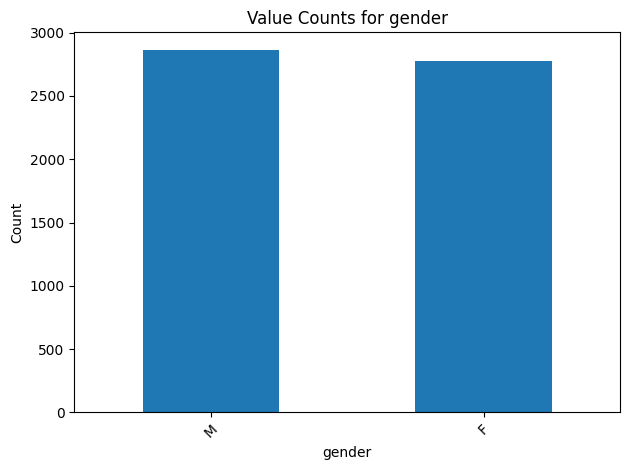

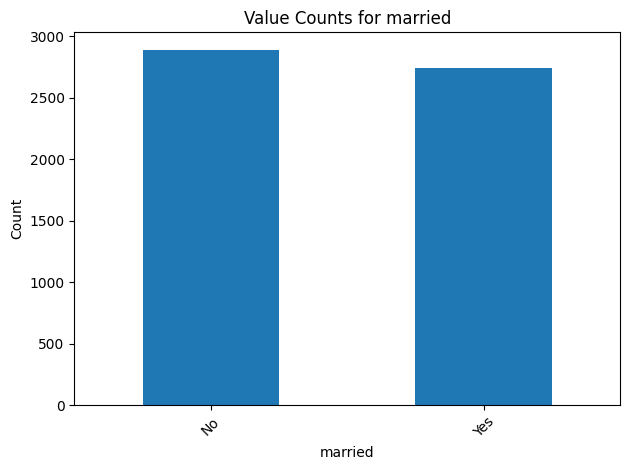

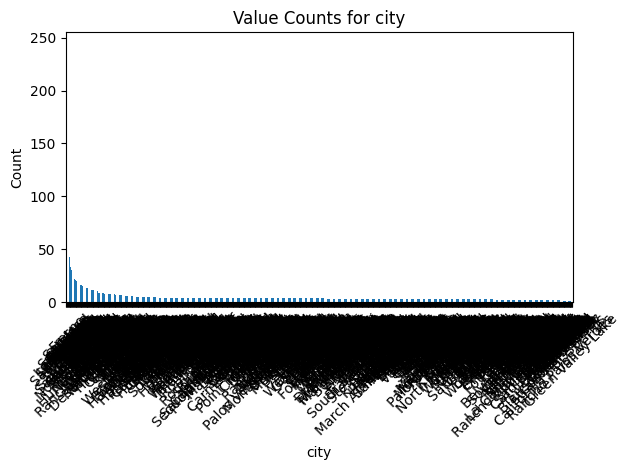

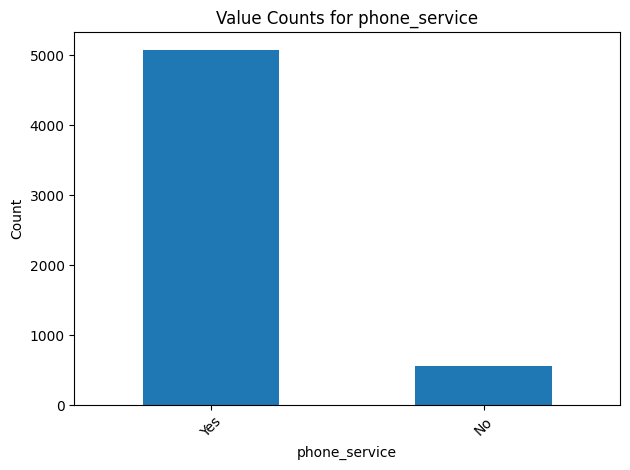

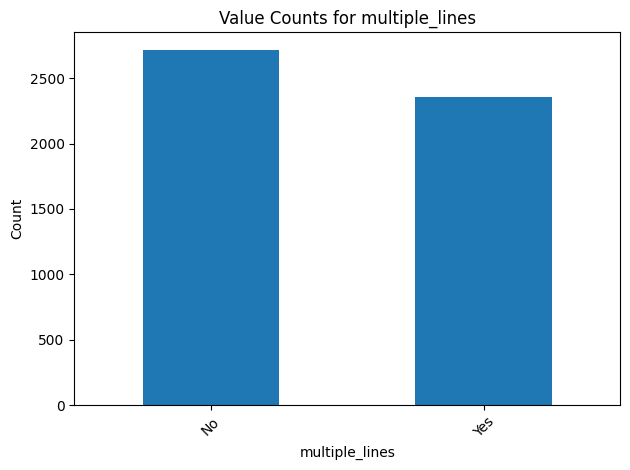

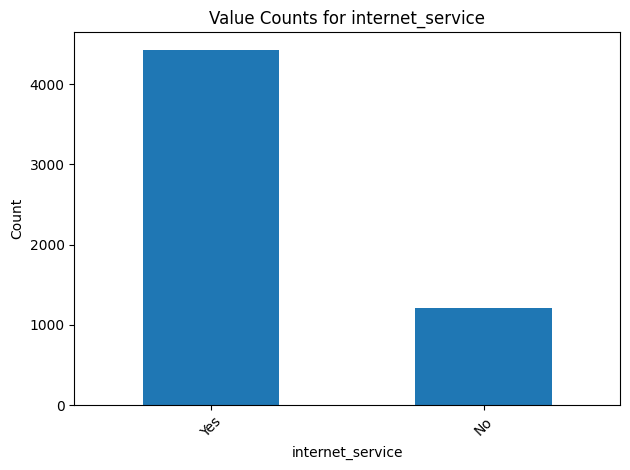

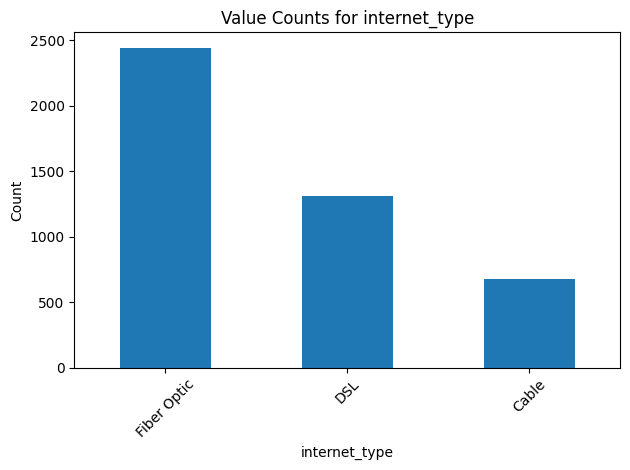

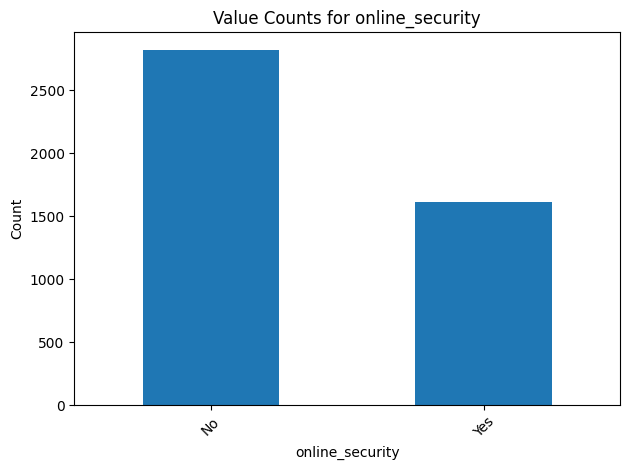

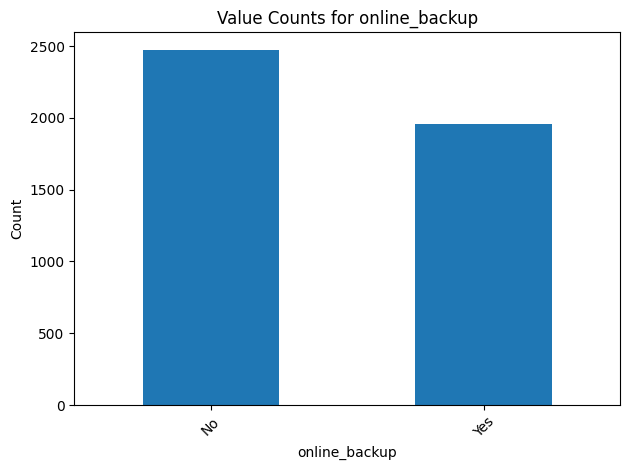

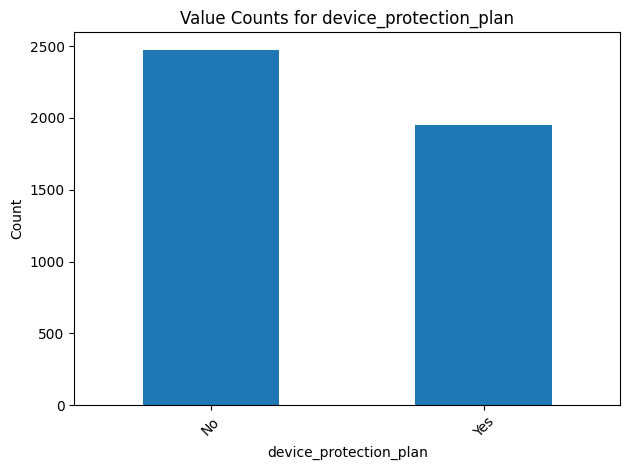

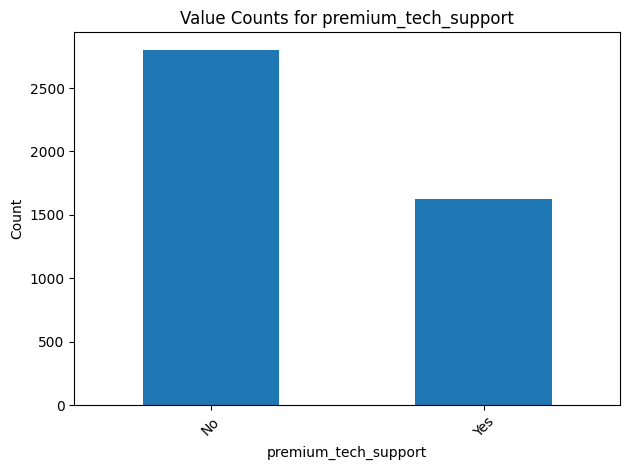

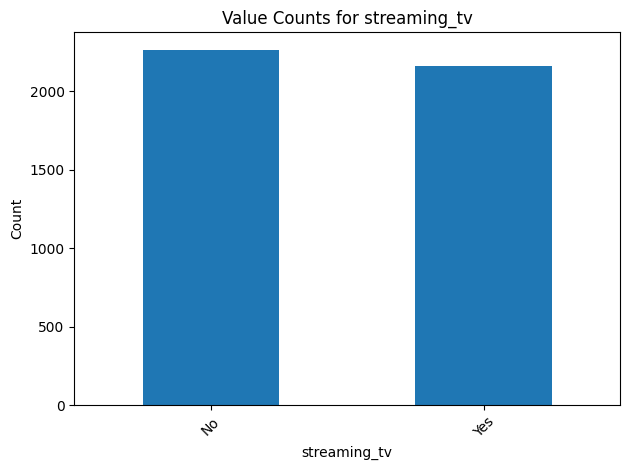

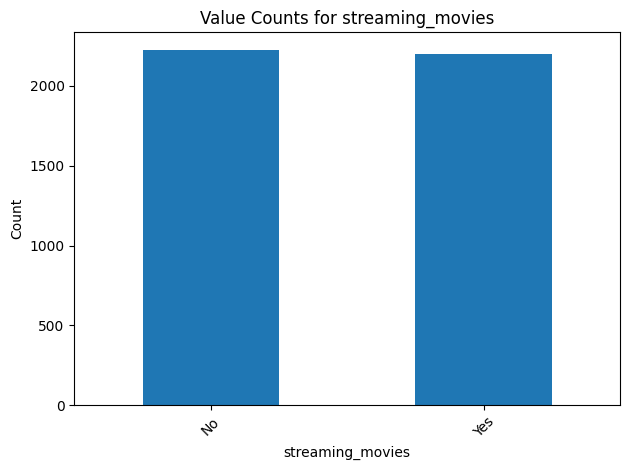

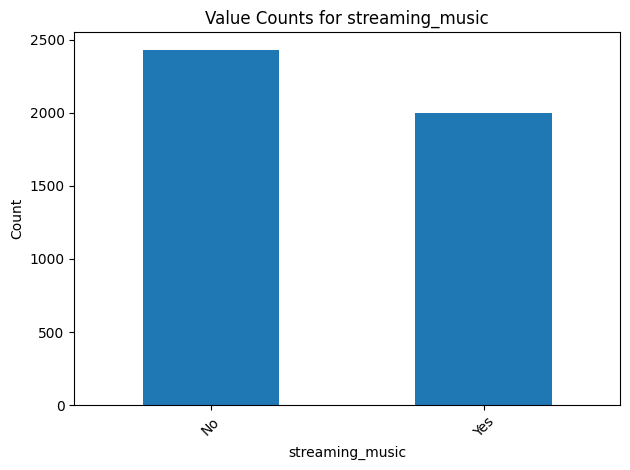

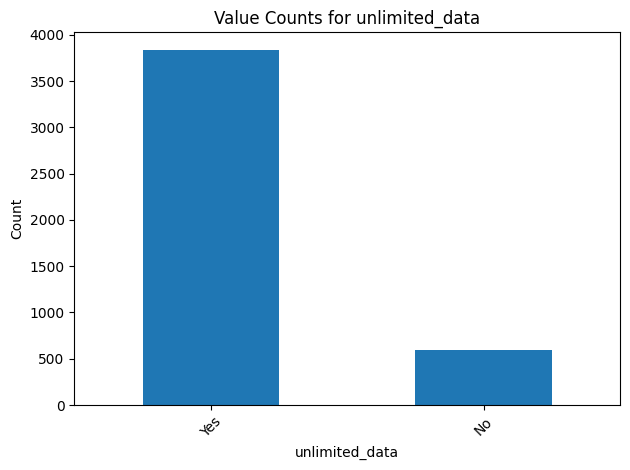

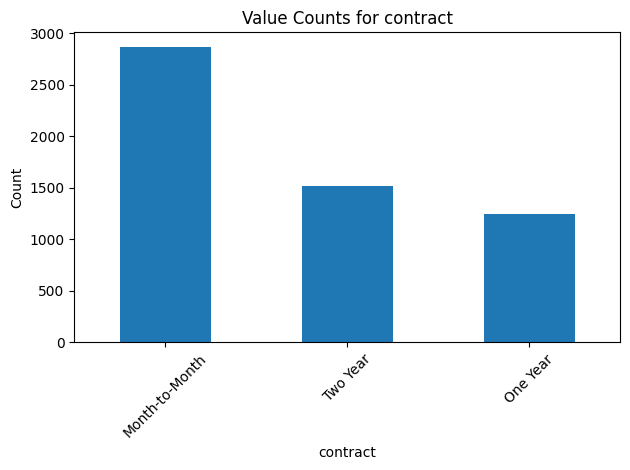

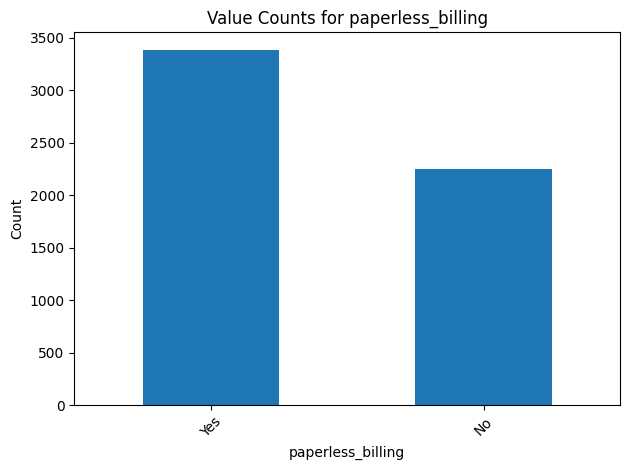

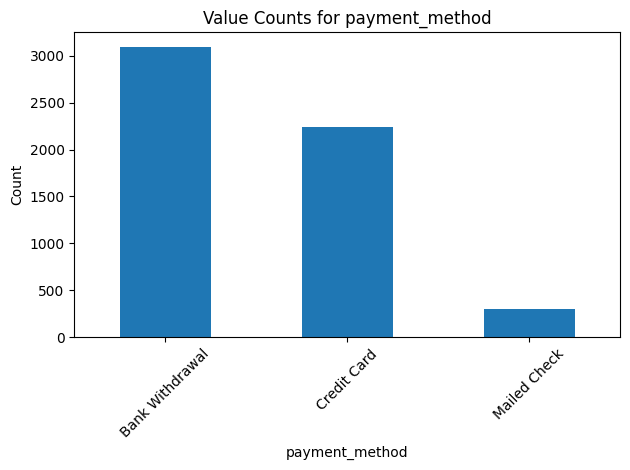

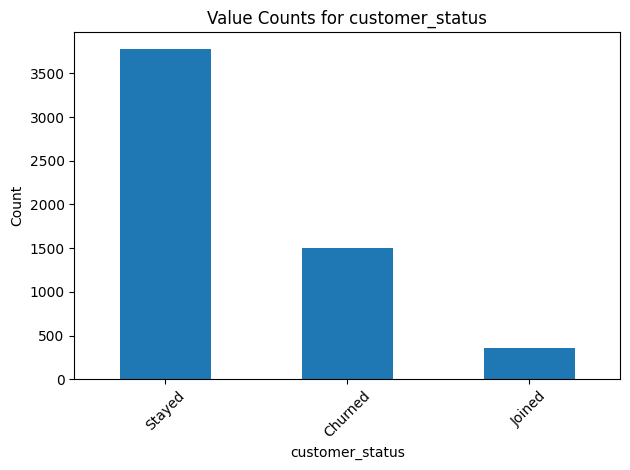

In [17]:
for column in categorical_columns:
    plt.figure()
    df[column].value_counts().plot(kind = 'bar')
    plt.title(f"Value Counts for {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

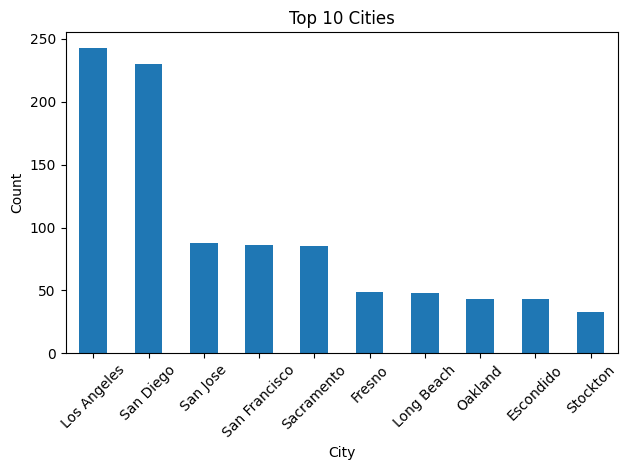

In [18]:
df["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
churn_df = df[df['customer_status'] == 'Churned']

In [20]:
# --Map Visualization
import folium

# Center map 
map_center = [df["latitude"].mean(), df["longitude"].mean()]

churn_map = folium.Map(location=map_center, zoom_start=6)

for _, row in churn_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
        popup=row["city"],
        fill=True
    ).add_to(churn_map)

churn_map
